### ***Assignment 1***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/zomato.csv', encoding = 'latin')
df1.head(86)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,6713772,Sainte Marie Gastronomia,30,Sí£o Paulo,"Rua Dom Joí£o Batista da Costa, 70, Vila SíÇni...",Vila SíÇnia,"Vila SíÇnia, Sí£o Paulo",-46.746958,-23.609207,"Lebanese, Arabian",...,Brazilian Real(R$),No,No,No,No,4,4.1,Green,Very Good,11
82,17284404,Austin's BBQ and Oyster Bar,216,Albany,"2820 Meredyth Dr, Albany, GA 31707",Albany,"Albany, Albany",-84.221535,31.610387,"BBQ, Burger, Seafood",...,Dollar($),No,No,No,No,2,3.3,Orange,Average,35
83,17284203,BJ's Country Buffet,216,Albany,"2401 Dawson Rd, Albany, GA 31707",Albany,"Albany, Albany",-84.207095,31.608743,"American, BBQ",...,Dollar($),No,No,No,No,1,3.3,Orange,Average,25
84,17284105,Cookie Shoppe,216,Albany,"115 N Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.154000,31.577200,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,34


In [ ]:
#Q1 How many missing values are present in each column, and how would you handle them (drop, fill, or impute)?

missing_values = pd.isna(df1).sum()
print(missing_values)
print('\n\n')
df1_filled = df1.fillna({'Cuisines' : '''He doesn't know waht to eat??'''})
print(df1_filled.head(86))
missing_values2 = pd.isna(df1_filled).sum()
print(missing_values2)

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64



    Restaurant ID                Restaurant Name  Country Code  \
0         6317637               Le Petit Souffle           162   
1         6304287               Izakaya Kikufuji           162   
2         6300002         Heat - Edsa Shangri-La           162   
3         6318506                           Ooma           162   
4         6314302                    Sambo Kojin           162   
..            ...                         

In [ ]:
#Q2 How can you filter restaurants that have Aggregate rating greater than 4.0 and Votes more than 100?

filter_df1 = df1[(df1['Aggregate rating'] > 4.0) & (df1['Votes'] > 100)]
print(filter_df1.head(86))

     Restaurant ID                   Restaurant Name  Country Code  \
0          6317637                  Le Petit Souffle           162   
1          6304287                  Izakaya Kikufuji           162   
2          6300002            Heat - Edsa Shangri-La           162   
3          6318506                              Ooma           162   
4          6314302                       Sambo Kojin           162   
..             ...                               ...           ...   
198       17330604  Burt's Butcher Shoppe and Eatery           216   
202       17330309                   Mellow Mushroom           216   
203       17330311                          Meritage           216   
204       17330615      Mongo The Mongolian Fire Pit           216   
205       17330638                     The Black Cow           216   

                 City                                            Address  \
0         Makati City  Third Floor, Century City Mall, Kalayaan Avenu...   
1      

In [ ]:
#Q3 Filter restaurants that provide Online delivery = Yes and are currently delivering now = Yes.

filter_yes = filter_df1 = df1[(df1['Has Online delivery'] == 'Yes') & (df1['Is delivering now'] == 'Yes')]
print(filter_yes)

      Restaurant ID              Restaurant Name  Country Code        City  \
787          122003            The Night Factory             1  Chandigarh   
1343       18204847                    Cake 24x7             1     Gurgaon   
1345       18294819                   Cake Point             1     Gurgaon   
1356         305096            Grandma's Kitchen             1     Gurgaon   
1403         311494                   Dabba Meat             1     Gurgaon   
1411       18070480               Monster's Cafe             1     Gurgaon   
1470         305790       Captain Bill$ Deliverz             1     Gurgaon   
1534         313204                        E Yum             1     Gurgaon   
1769       18025110       Captain Bill$ Deliverz             1     Gurgaon   
1988       18439540                Ullu Delivers             1     Gurgaon   
2021       18439516  Brother's Snacks and Shakes             1     Gurgaon   
2047         307502       Captain Bill$ Deliverz             1  

In [ ]:
#Q4 Filter the top 10 restaurants with the highest Votes

print(df1.sort_values(by = 'Votes',ascending = False).head(10))

      Restaurant ID            Restaurant Name  Country Code       City  \
728           51705                       Toit             1  Bangalore   
735           51040                   Truffles             1  Bangalore   
3994         308322           Hauz Khas Social             1  New Delhi   
2412          20404                  Peter Cat             1    Kolkata   
739           56618  AB's - Absolute Barbecues             1  Bangalore   
2414          20842            Barbeque Nation             1    Kolkata   
743           58882                Big Brewsky             1  Bangalore   
2307          94286  AB's - Absolute Barbecues             1  Hyderabad   
736           54162            The Black Pearl             1  Bangalore   
2411          20870                      BarBQ             1    Kolkata   

                                                Address  \
728   298, Namma Metro Pillar 62, 100 Feet Road, Ind...   
735   28, 4th 'B' Cross, Koramangala 5th Block, Bang... 

In [ ]:
#Q5 Filter restaurants that serve a specific Cuisine (e.g., “Italian”).
df_italian = df1[df1['Cuisines'] == 'Italian']

print(df_italian)

      Restaurant ID                     Restaurant Name  Country Code  \
31          6600083                        Villa Tevere            30   
40          6600116                                Gero            30   
53          7304312                    D.O.C Ristorante            30   
76          6705858                    Terraí_o Itíçlia            30   
115        17293273            La Dolce Vita Ristorante           216   
217        17334254   Tony's Italian Restaurant & Pizza           216   
233        17334965                  Trattoria Tiramisu           216   
274        17342799                    Vinny Vanucchi's           216   
335        17501201                    My Fathers Place           216   
357        17059541             Maggiano's Little Italy           216   
463        18483714                Fratini La Trattoria           184   
494        17621946                    Trattoria Fresco           216   
532        17678097      Mom & Dad's Italian Restau

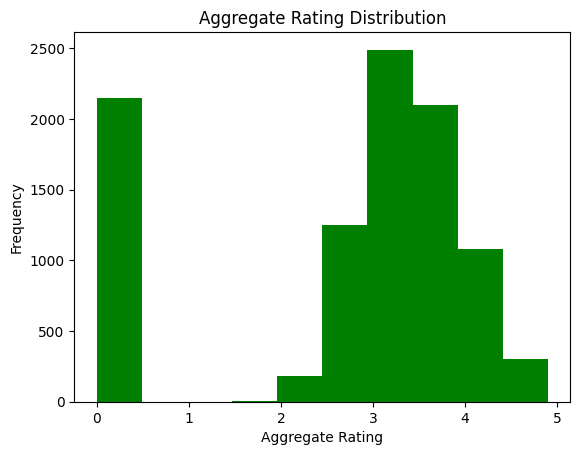

In [ ]:
#Q6 Using Matplotlib, plot the distribution of Aggregate rating. What does the distribution tell you?
plt.hist(df1['Aggregate rating'], color = 'green')
plt.title('Aggregate Rating Distribution')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.show()

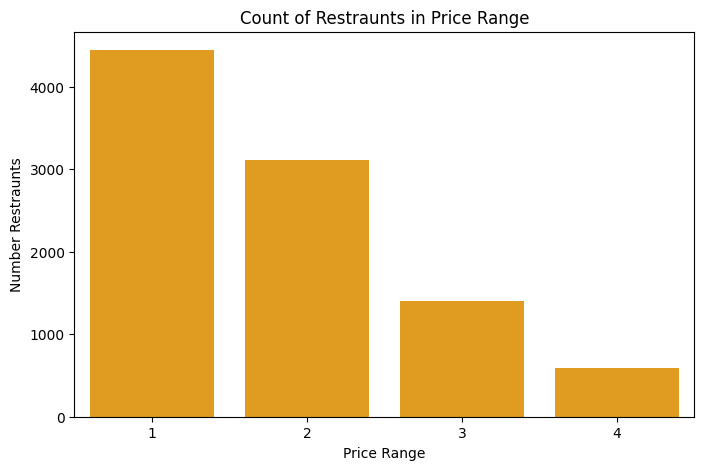

In [ ]:
#Q7 Create a Seaborn count plot for Price range. Which price range category has the most restaurants?

plt.figure(figsize = (8, 5))
sns.countplot(x = 'Price range', data = df1, color = 'orange')
plt.xlabel('Price Range')
plt.ylabel('Number Restraunts')
plt.title('Count of Restraunts in Price Range')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'New Delhi'),
  Text(1, 0, 'Gurgaon'),
  Text(2, 0, 'Noida'),
  Text(3, 0, 'Faridabad'),
  Text(4, 0, 'Ghaziabad'),
  Text(5, 0, 'Bhubaneshwar'),
  Text(6, 0, 'Lucknow'),
  Text(7, 0, 'Ahmedabad'),
  Text(8, 0, 'Amritsar'),
  Text(9, 0, 'Guwahati')])

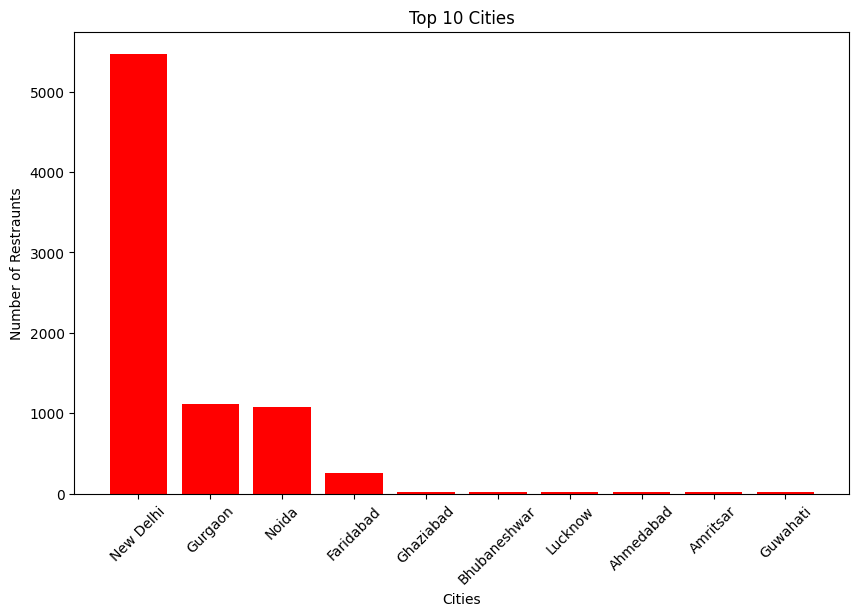

In [ ]:
#Q8 Using Matplotlib, create a bar chart showing the number of restaurants in the top 10 Cities.
top10 = df1['City'].value_counts().head(10)
plt.figure(figsize = (10,6))
plt.bar(top10.index, top10.values, color = 'red')
plt.xlabel('Cities')
plt.ylabel('Number of Restraunts')
plt.title('Top 10 Cities')
plt.xticks(rotation = 45)

Text(0.5, 1.0, 'Distribution of Average Cost for Two by Price Range')

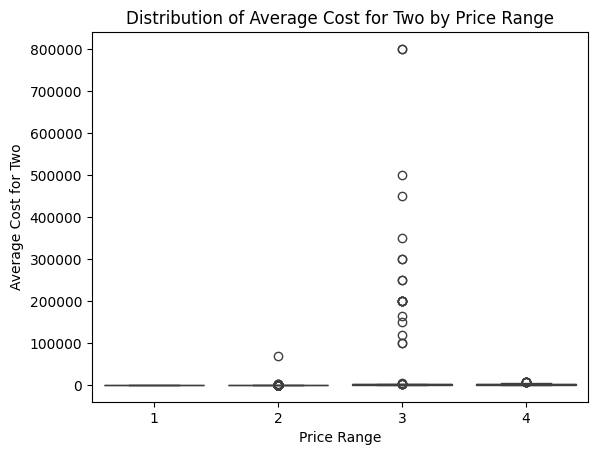

In [ ]:
#Q9 Using Seaborn, create a boxplot of Average Cost for two across different Price range categories. What insights can you observe?

sns.boxplot(x = 'Price range', y = 'Average Cost for two' , data = df1)
plt.xlabel('Price Range')
plt.ylabel('Average Cost for Two')
plt.title('Distribution of Average Cost for Two by Price Range')


Text(0.5, 1.0, 'Relation between Aggregate Rating and Votes')

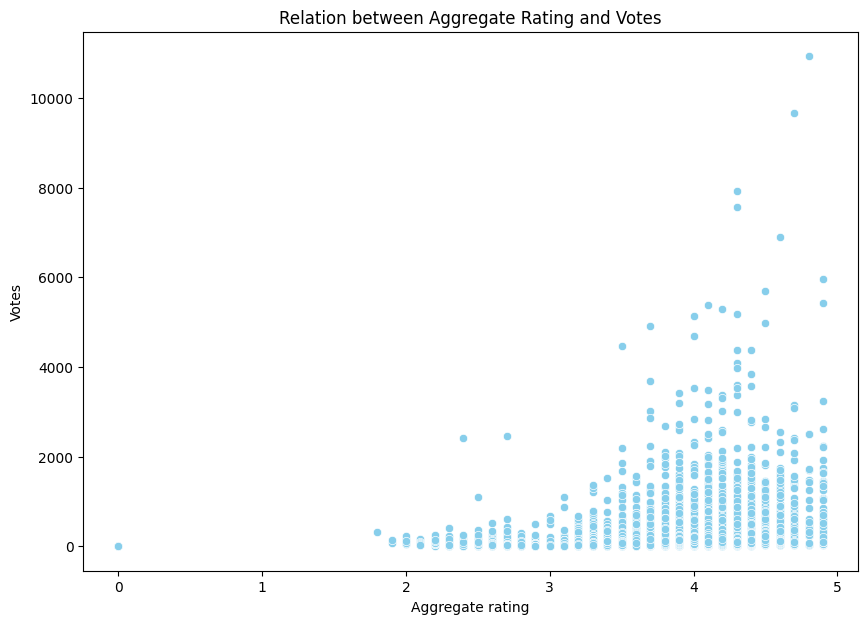

In [ ]:
#Q10 Is there a relationship between Aggregate rating and Votes? Visualize it using a Seaborn scatterplot.

plt.figure(figsize = (10,7))
sns.scatterplot(x = 'Aggregate rating', y = 'Votes', data = df1, color = 'skyblue')
plt.title('Relation between Aggregate Rating and Votes')

Text(0.5, 1.0, 'Correlation Heatmap of Numeric Features')

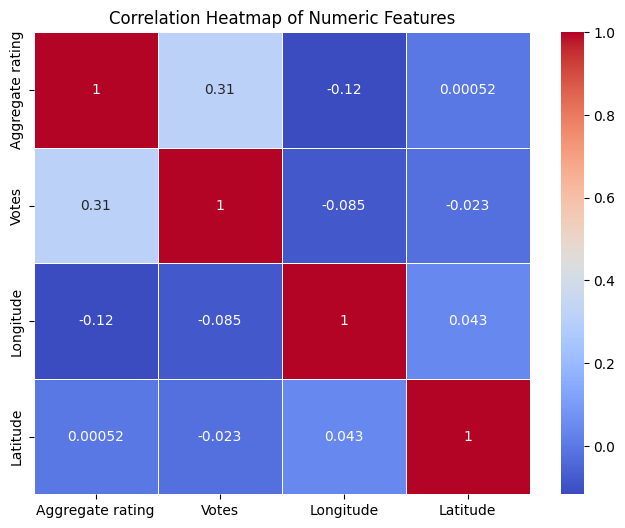

In [ ]:
#Q11 Create a correlation heatmap (Seaborn) for numerical features like Longitude, Latitude, Average Cost for two, Aggregate rating, Votes. What correlations do you observe?

numeric_cols = ['Aggregate rating', 'Votes', 'Longitude', 'Latitude']
corelation_Matrix = df1[numeric_cols].corr()
plt.figure(figsize = (8,6))
sns.heatmap(corelation_Matrix, annot = True, cmap = 'coolwarm', linewidths= 0.5)
plt.title('Correlation Heatmap of Numeric Features')

Text(0.5, 1.0, 'Number of Restaurants by Country Code')

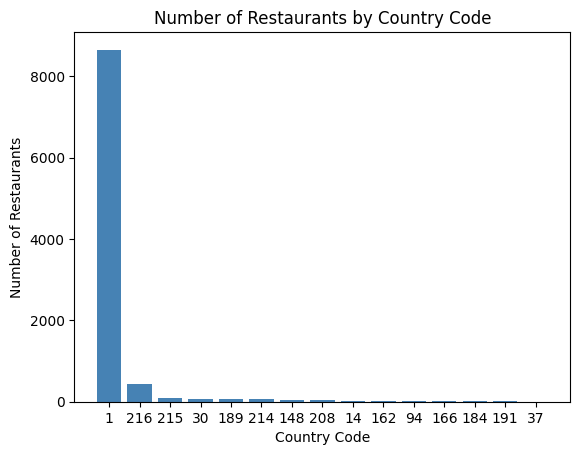

In [ ]:
#Q12 Using Matplotlib, plot the number of restaurants by Country Code. Which country has the highest number?

# country_count = df1['Country Code'].value_counts()



# plt.bar(country_count.index, country_count.values, color='skyblue')
country_count = df1['Country Code'].value_counts().sort_values(ascending=False)
plt.bar(country_count.index.astype(str), country_count.values, color='steelblue')
plt.xlabel('Country Code')
plt.ylabel('Number of Restaurants')
plt.title('Number of Restaurants by Country Code')

Text(0, 0.5, 'Average Aggregate Rating')

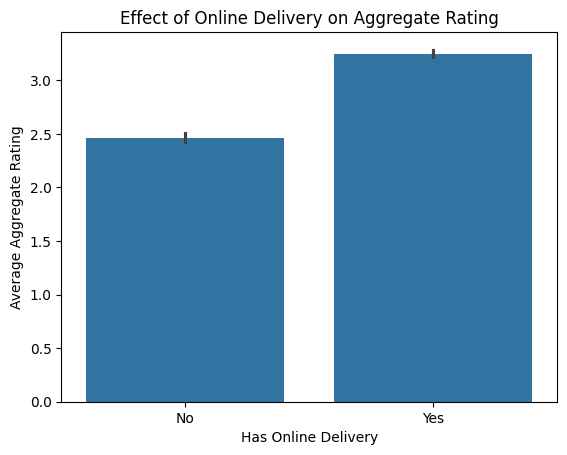

In [ ]:
#Q13 How does Has Online delivery affect Aggregate rating? Visualize using a Seaborn bar plot.

# yes_no_int = df1.
# sns.barplot(df1['Has Online delivery'], df1['Aggregate rating'], color = 'blue')
sns.barplot(x = 'Has Online delivery', y = 'Aggregate rating', data = df1)
plt.title('Effect of Online Delivery on Aggregate Rating')
plt.xlabel('Has Online Delivery')
plt.ylabel('Average Aggregate Rating')

    Restaurant ID                           Restaurant Name  Country Code  \
0         6317637                          Le Petit Souffle           162   
1         6304287                          Izakaya Kikufuji           162   
2         6300002                    Heat - Edsa Shangri-La           162   
3         6318506                                      Ooma           162   
4         6314302                               Sambo Kojin           162   
5        18189371                              Din Tai Fung           162   
6         6300781                                Buffet 101           162   
7         6301290                                   Vikings           162   
8         6300010  Spiral - Sofitel Philippine Plaza Manila           162   
9         6314987                                  Locavore           162   
10        6309903                          Silantro Fil-Mex           162   
11        6309455           Mad Mark's Creamery & Good Eats           162   

<Axes: xlabel='Has Online delivery', ylabel='Aggregate rating'>

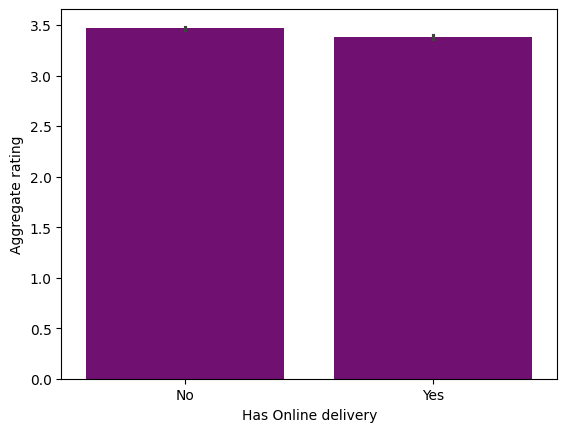

In [ ]:
#Q14 Identify and remove restaurants with Aggregate rating = 0. How does this affect the overall rating distribution?

zero_rating = df1[df1['Aggregate rating'] != 0]
print(zero_rating.head(36))
sns.barplot(y = zero_rating['Aggregate rating'],x = zero_rating['Has Online delivery'], color = 'purple')

Text(0, 0.5, 'Number of Restaurants')

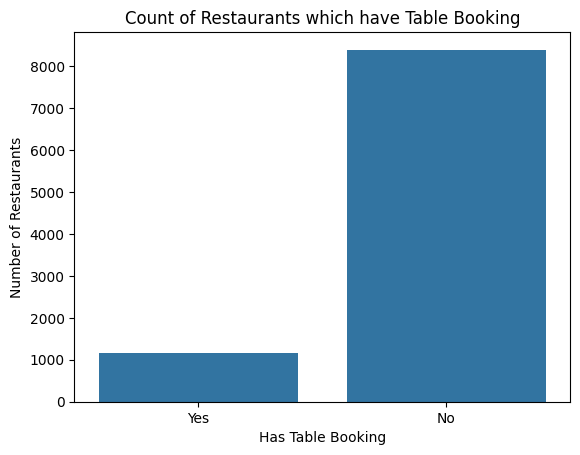

In [ ]:
#Q15 Create a Seaborn count plot to compare restaurants that have Table booking vs those that don’t. Which category is more common?

# table_booking = df1[df1['Has Table booking'] == 'Yes'].value_counts()
# no_table_booking = df1[df1['Has Table booking'] == 'No'].value_counts()

# print(table_booking)
# print(no_table_booking)

sns.countplot(x = 'Has Table booking', data = df1)
plt.title('Count of Restaurants which have Table Booking')
plt.xlabel('Has Table Booking')
plt.ylabel('Number of Restaurants')

### **Assignment 2**

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
df2 = pd.read_csv('/content/drive/MyDrive/tip dataset.csv')
df2

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,9.68,Michael Avila,5296068606052842,Sat2657
240,27.18,2.00,Female,Yes,Sat,Dinner,2,13.59,Monica Sanders,3506806155565404,Sat1766
241,22.67,2.00,Male,Yes,Sat,Dinner,2,11.34,Keith Wong,6011891618747196,Sat3880
242,17.82,1.75,Male,No,Sat,Dinner,2,8.91,Dennis Dixon,4375220550950,Sat17


Q1. Describe the dataset and list all columns.

The dataset was explored using df2.head() to view the first few rows and understand the structure of the data. The df2.info() function was used to display information about the dataset such as the number of entries, column names, data types, and missing values. The df2.columns function was used to list all the column names present in the dataset.



In [22]:
# Display first few rows of the dataset
print(df2.head())

# Show dataset structure
print(df2.info())

# Print column names
print("\nAll Column Names:\n", df2.columns)

   total_bill   tip     sex smoker  day    time  size  price_per_person  \
0       16.99  1.01  Female     No  Sun  Dinner     2              8.49   
1       10.34  1.66    Male     No  Sun  Dinner     3              3.45   
2       21.01  3.50    Male     No  Sun  Dinner     3              7.00   
3       23.68  3.31    Male     No  Sun  Dinner     2             11.84   
4       24.59  3.61  Female     No  Sun  Dinner     4              6.15   

           Payer Name         CC Number Payment ID  
0  Christy Cunningham  3560325168603410    Sun2959  
1      Douglas Tucker  4478071379779230    Sun4608  
2      Travis Walters  6011812112971322    Sun4458  
3    Nathaniel Harris  4676137647685994    Sun5260  
4        Tonya Carter  4832732618637221    Sun2251  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   total_bill        244 non-n

Q2. Identify numerical and categorical variables.

Numerical variables are continuous values like total_bill, tip, size, and price_per_person.

Categorical variables are text-based or category features like sex, smoker, day, and time. Identifying them helps in preprocessing and selecting the right model.


In [23]:
# Q2
numerical_cols = df2.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df2.select_dtypes(include=['object', 'category']).columns

print("Numerical Columns:\n", numerical_cols)
print("\nCategorical Columns:\n", categorical_cols)

Numerical Columns:
 Index(['total_bill', 'tip', 'size', 'price_per_person', 'CC Number'], dtype='object')

Categorical Columns:
 Index(['sex', 'smoker', 'day', 'time', 'Payer Name', 'Payment ID'], dtype='object')


Q3. Identify irrelevant columns for ML modeling and justify

Columns like Payer Name, CC Number, and Payment ID are irrelevant for machine learning because they are unique identifiers or sensitive information that do not help the model learn patterns. Removing them ensures the model focuses only on more useful features.


In [24]:
# Q3
irrelevant_cols = ['Payer Name', 'CC Number', 'Payment ID']
df2 = df2.drop(columns=irrelevant_cols, errors='ignore')
print("Columns after removing irrelevant ones:\n", df2.columns)

Columns after removing irrelevant ones:
 Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size',
       'price_per_person'],
      dtype='object')


Q4. Define Features and Labels for Regression and Classification.

Features are the input variables used by the model, while the label is the variable we want to predict. In this dataset, features include total_bill, sex, smoker, day, time, size, and price_per_person, while the label can be tip (for regression) or another target column (for classification).


In [25]:
# Q4.

# Features (independent variables)
X = df2.drop(columns=['tip'], errors='ignore')

# Labels (dependent variable)
y = df2['tip']

print("Features (X) columns:\n", X.columns)
print("\nLabels (y) column:\n", y.name)

Features (X) columns:
 Index(['total_bill', 'sex', 'smoker', 'day', 'time', 'size',
       'price_per_person'],
      dtype='object')

Labels (y) column:
 tip


Q5. Differentiate between Regression and Classification with examples


Regression predicts numerical values, such as the tip amount in this dataset, using features like total_bill, size, and day. Classification predicts categories, such as the time of meal (Lunch or Dinner), based on similar features. Choosing the correct problem type is important because it determines the model, output format, and loss function. For example, regression uses metrics like MSE to measure error, while classification uses metrics like accuracy or crossentropy.



Q6. Classify the following tasks: predicting tip, predicting smoker, predicting total bill.

Predicting tip is a regression task because the tip is a continuous numerical value, and the model needs to predict an exact amount.

Predicting smoker is a classification task because it is a categorical variable with two possible values (Yes or No), so the model predicts a class instead of a number.

Predicting total_bill is also a regression task since the total bill is a continuous number, and the model needs to estimate its value based on other features like size, day, and time.


Q7. Perform data cleaning (missing values, duplicates, encoding)

Data cleaning involves handling missing values, duplicates, and encoding categorical variables. First, missing values were checked using isnull() and any rows with missing data were dropped. Duplicate rows were identified and removed to prevent redundancy. Categorical columns such as sex, smoker, day, and time were converted into numerical format using one-hot encoding, which allows the model to process them correctly.


In [26]:
# Q7
print("Missing values per column:\n", df2.isnull().sum())
df2 = df2.dropna()  # drops rows with missing values
print("After dropping missing values, dataset shape:", df2.shape)

duplicates = df2.duplicated().sum()
print("Number of duplicate rows:", duplicates)
df2 = df2.drop_duplicates()
print("After removing duplicates, dataset shape:", df2.shape)

df2 = pd.get_dummies(df2, columns=['sex', 'smoker', 'day', 'time'], drop_first=True)
print("Columns after encoding:\n", df2.columns)

Missing values per column:
 total_bill          0
tip                 0
sex                 0
smoker              0
day                 0
time                0
size                0
price_per_person    0
dtype: int64
After dropping missing values, dataset shape: (244, 8)
Number of duplicate rows: 1
After removing duplicates, dataset shape: (243, 8)
Columns after encoding:
 Index(['total_bill', 'tip', 'size', 'price_per_person', 'sex_Male',
       'smoker_Yes', 'day_Sat', 'day_Sun', 'day_Thur', 'time_Lunch'],
      dtype='object')


Q8. Perform statistical analysis (mean, median, std)

Statistical analysis helps summarize the main characteristics of numerical data. Here, mean, median, and standard deviation were calculated for total_bill, tip, size, and price_per_person to understand the central tendency and spread of the data. This helps identify trends, variations, and potential outliers in the dataset.


In [15]:
# Q8

# Select numerical columns for analysis
stat_cols = df2[['total_bill', 'tip', 'size', 'price_per_person']]

# Display first 5 rows for reference
print("First 5 rows of selected columns:\n", stat_cols.head())

# Calculate and display mean
print("\nMean values:\n", stat_cols.mean())

# Calculate and display median
print("\nMedian values:\n", stat_cols.median())

# Calculate and display standard deviation
print("\nStandard deviation:\n", stat_cols.std())

First 5 rows of selected columns:
    total_bill   tip  size  price_per_person
0       16.99  1.01     2              8.49
1       10.34  1.66     3              3.45
2       21.01  3.50     3              7.00
3       23.68  3.31     2             11.84
4       24.59  3.61     4              6.15

Mean values:
 total_bill          19.813868
tip                  3.002387
size                 2.572016
price_per_person     7.893909
dtype: float64

Median values:
 total_bill          17.81
tip                  2.92
size                 2.00
price_per_person     7.26
dtype: float64

Standard deviation:
 total_bill          8.910071
tip                 1.385002
size                0.952356
price_per_person    2.918880
dtype: float64


Q9. Perform correlation analysis and interpret relationships.

Looking at the correlation, total_bill and tip are strongly positively correlated, which makes sense because bigger bills usually mean bigger tips. price_per_person also goes up with total_bill and tip. Size has some positive correlation with total_bill but isn’t super strong with tip. Understanding these relationships can help decide which features are useful for the model.


Here’s the correlation between features:
                   total_bill       tip      size  price_per_person
total_bill          1.000000  0.674998  0.597589          0.647134
tip                 0.674998  1.000000  0.488400          0.346520
size                0.597589  0.488400  1.000000         -0.176752
price_per_person    0.647134  0.346520 -0.176752          1.000000 



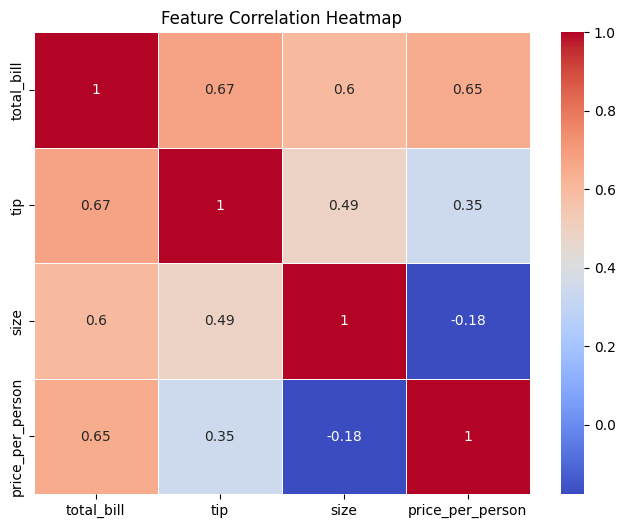

In [31]:
# Q9

# Picking only numerical columns to see how they relate
num_cols = df2[['total_bill', 'tip', 'size', 'price_per_person']]

# Checking correlation numbers
corr_matrix = num_cols.corr()
print("Here’s the correlation between features:\n", corr_matrix, "\n")

# Making a heatmap to visualize it
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [33]:
print(df2.columns)

Index(['total_bill', 'tip', 'size', 'price_per_person', 'sex_Male',
       'smoker_Yes', 'day_Sat', 'day_Sun', 'day_Thur', 'time_Lunch'],
      dtype='object')


Q10. Perform group analysis (gender, smoker, day, time).

Since our dataset has only one-hot encoded columns, we used those to calculate average tips. For gender, we used 'sex_Male' (Female is everyone else). For smoker, we used 'smoker_Yes'. For days, we only have Thursday, Saturday, and Sunday, so we used those columns. For time, only Lunch exists, so Dinner is everyone else. This lets us see how tips change across different groups even after encoding.

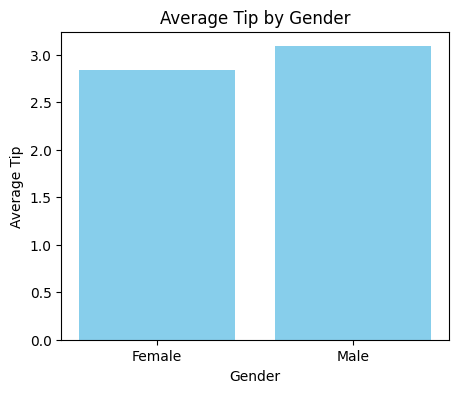

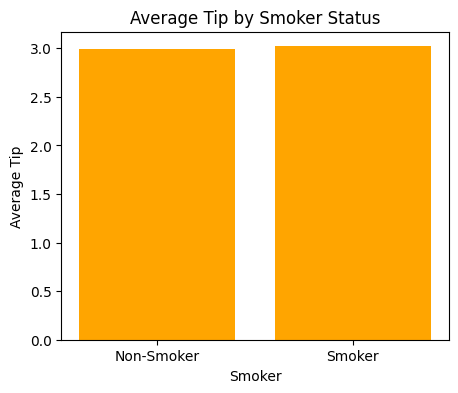

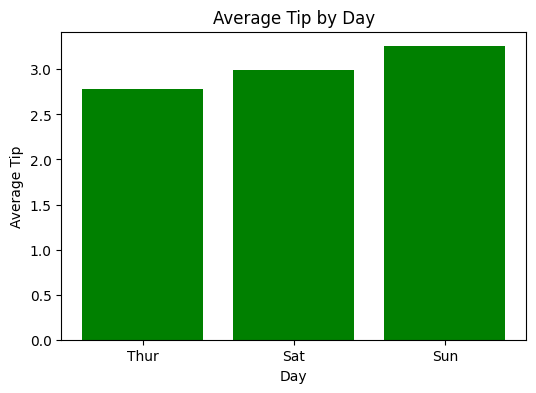

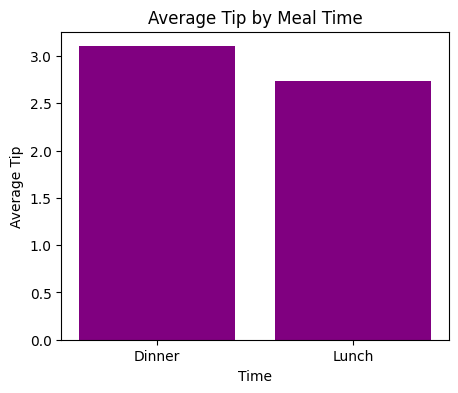

In [39]:
# Q10. Perform group analysis (gender, smoker, day, time).

# Gender: Male vs Female
# We only got 'sex_Male', so Female = not Male by encoding
avg_tip_male = df2[df2['sex_Male']==1]['tip'].mean()
avg_tip_female = df2[df2['sex_Male']==0]['tip'].mean()

plt.figure(figsize=(5,4))
plt.bar(['Female', 'Male'], [avg_tip_female, avg_tip_male], color='skyblue')
plt.title('Average Tip by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Tip')
plt.show()

# Smoker: Yes vs No
avg_tip_smoker = df2[df2['smoker_Yes']==1]['tip'].mean()
avg_tip_nonsmoker = df2[df2['smoker_Yes']==0]['tip'].mean()

plt.figure(figsize=(5,4))
plt.bar(['Non-Smoker', 'Smoker'], [avg_tip_nonsmoker, avg_tip_smoker], color='orange')
plt.title('Average Tip by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Average Tip')
plt.show()

# Days we've in dataset: only have Sat, Sun, Thur
days = ['day_Thur', 'day_Sat', 'day_Sun']
avg_tips_day = [df2[df2[day]==1]['tip'].mean() for day in days]

plt.figure(figsize=(6,4))
plt.bar(['Thur', 'Sat', 'Sun'], avg_tips_day, color='green')
plt.title('Average Tip by Day')
plt.xlabel('Day')
plt.ylabel('Average Tip')
plt.show()

# Time: only Lunch exists, so Dinner = not Lunch
avg_tip_lunch = df2[df2['time_Lunch']==1]['tip'].mean()
avg_tip_dinner = df2[df2['time_Lunch']==0]['tip'].mean()

plt.figure(figsize=(5,4))
plt.bar(['Dinner', 'Lunch'], [avg_tip_dinner, avg_tip_lunch], color='purple')
plt.title('Average Tip by Meal Time')
plt.xlabel('Time')
plt.ylabel('Average Tip')
plt.show()

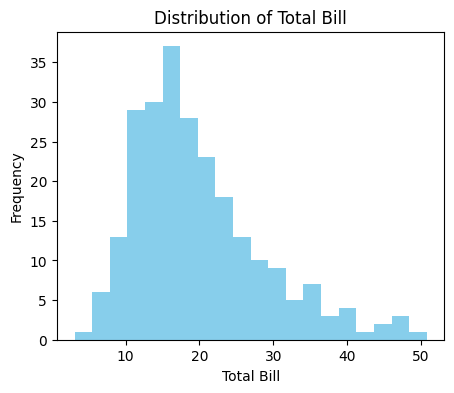

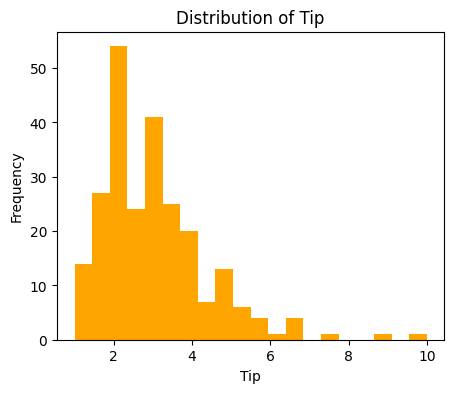

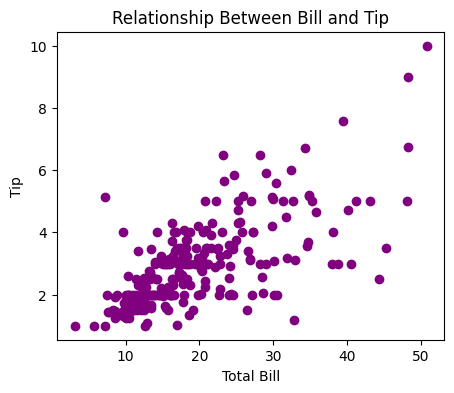

/tmp/ipykernel_1426/2065305553.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(tips_by_day, labels=['Thur', 'Sat', 'Sun'])


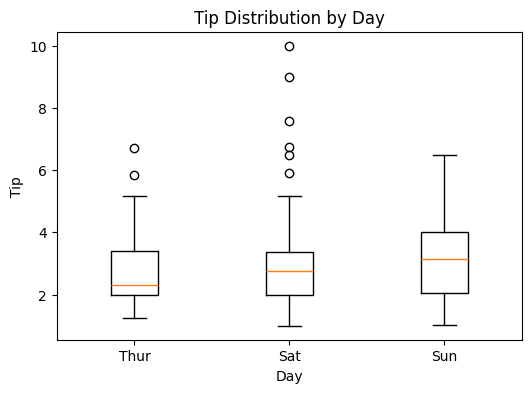

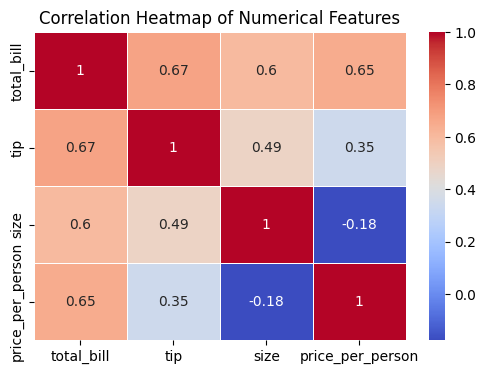

In [42]:
# Q11. Create visualizations (scatter, boxplot, histogram, heatmap).

# Histogram for Total Bill
plt.figure(figsize=(5,4))
plt.hist(df2['total_bill'], color='skyblue', bins=20)
plt.title('Distribution of Total Bill')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.show()

# Histogram for Tip
plt.figure(figsize=(5,4))
plt.hist(df2['tip'], color='orange', bins=20)
plt.title('Distribution of Tip')
plt.xlabel('Tip')
plt.ylabel('Frequency')
plt.show()

# Scatter plot for Total Bill vs Tip
plt.figure(figsize=(5,4))
plt.scatter(df2['total_bill'], df2['tip'], color='purple')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Relationship Between Bill and Tip')
plt.show()

# Boxplot for tips by day (using one-hot encoded columns)
days = ['day_Thur', 'day_Sat', 'day_Sun']
tips_by_day = [df2[df2[day]==1]['tip'] for day in days]

plt.figure(figsize=(6,4))
plt.boxplot(tips_by_day, labels=['Thur', 'Sat', 'Sun'])
plt.title('Tip Distribution by Day')
plt.xlabel('Day')
plt.ylabel('Tip')
plt.show()

# Heatmap of correlations between numerical features
num_cols = ['total_bill', 'tip', 'size', 'price_per_person']
plt.figure(figsize=(6,4))
sns.heatmap(df2[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Q 12 Develop Linear Regression model to predict tip.

The regression equation can be written as:

**Tip = Intercept + (Coefficient1 * total_bill) + (Coefficient2 * size) + (Coefficient3 * sex_Male) + ...**

Each coefficient tells us how the tip changes if that feature increases by 1 unit, keeping everything else constant.

* Positive coefficient → feature increases the tip
* Negative coefficient → feature decreases the tip

For example, if `total_bill` has a positive coefficient, a higher bill means a higher tip. If `sex_Male` has a negative coefficient, it means males tip slightly less than females, all else equal.

This equation helps understand which features most affect tipping.


Intercept: 0.6521124808487286

             Coefficient
total_bill     0.085483
size           0.210989
sex_Male       0.018162
smoker_Yes    -0.052130
day_Sat        0.103283
day_Sun        0.167782
day_Thur      -0.049832
time_Lunch     0.194669

 MAE: 0.7665074194589537
MSE: 1.1730028226689762
RMSE: 1.0830525484338127
R2 Score: 0.5185656337107039


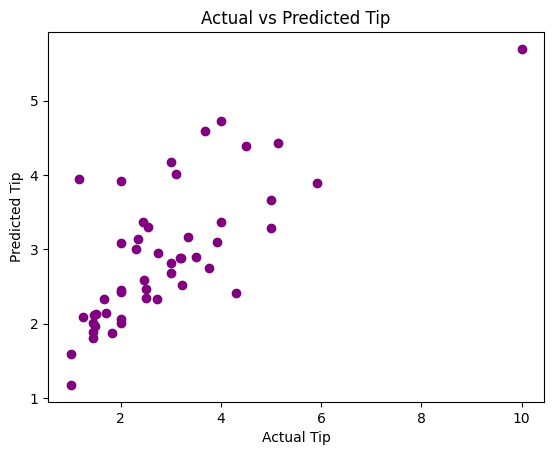

In [49]:
# Q12

# Features and target after encoding
X = df2.drop(['tip','price_per_person'], axis=1)
y = df2['tip']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Model parameters
print("Intercept:", model.intercept_)
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print('\n', coeff_df)  # shows how each feature affects tip

# Predictions
y_pred = model.predict(X_test)

# Performance metrics
print("\n MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Actual vs Predicted plot
plt.scatter(y_test, y_pred, color='purple')
plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tip")
plt.show()


Training Set Performance:
MAE: 0.74, MSE: 0.98, RMSE: 0.99, R²: 0.45

Test Set Performance:
MAE: 0.77, MSE: 1.17, RMSE: 1.08, R²: 0.52

Interpretation:
Training and testing performance are similar → model is generalizing well.


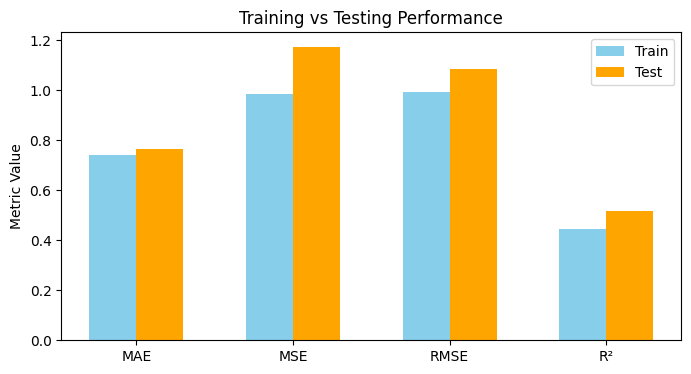

In [52]:
# Compare RMSE for train vs test
# Predictions
y_train_pred = model.predict(X_train)  # predict on training set
y_test_pred  = model.predict(X_test)   # predict on testing set

#  Training Metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train  = r2_score(y_train, y_train_pred)

# Testing metrics
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test  = r2_score(y_test, y_test_pred)

# Metrics
print("Training Set Performance:")
print(f"MAE: {mae_train:.2f}, MSE: {mse_train:.2f}, RMSE: {rmse_train:.2f}, R²: {r2_train:.2f}\n")

print("Test Set Performance:")
print(f"MAE: {mae_test:.2f}, MSE: {mse_test:.2f}, RMSE: {rmse_test:.2f}, R²: {r2_test:.2f}")

# Interpretation
print("\nInterpretation:")
if r2_train > r2_test + 0.1:
    print("The model performs better on training than testing → may be slightly overfitting.")
elif r2_train < r2_test - 0.1:
    print("The model performs better on testing than training → might be underfitting or data split variation.")
else:
    print("Training and testing performance are similar → model is generalizing well.")

# Visual comparasion of the Model
metrics = ['MAE', 'MSE', 'RMSE', 'R²']
train_values = [mae_train, mse_train, rmse_train, r2_train]
test_values  = [mae_test, mse_test, rmse_test, r2_test]

x = range(len(metrics))
plt.figure(figsize=(8,4))
plt.bar([i-0.15 for i in x], train_values, width=0.3, label='Train', color='skyblue')
plt.bar([i+0.15 for i in x], test_values, width=0.3, label='Test', color='orange')
plt.xticks(x, metrics)
plt.ylabel('Metric Value')
plt.title('Training vs Testing Performance')
plt.legend()
plt.show()

In [63]:
print(X.columns)

Index(['total_bill', 'tip', 'size', 'price_per_person', 'sex_Male', 'day_Sat',
       'day_Sun', 'day_Thur', 'time_Lunch'],
      dtype='object')


In [59]:
# Custom prediction
total_bill = float(input("Enter total bill amount: "))
size = int(input("Enter number of people: "))
sex_Male = int(input("Male? (1=yes, 0=no): "))
smoker_Yes = int(input("Smoker? (1=yes, 0=no): "))
day_Sat = int(input("Saturday? (1=yes, 0=no): "))
day_Sun = int(input("Sunday? (1=yes, 0=no): "))
day_Thur = int(input("Thursday? (1=yes, 0=no): "))
time_Lunch = int(input("Lunch? (1=yes, 0=no): "))

user_data = pd.DataFrame([[
    total_bill,
    size,
    sex_Male,
    smoker_Yes,
    day_Sat,
    day_Sun,
    day_Thur,
    time_Lunch
]], columns=X.columns)

pred_tip = model.predict(user_data)

print("Predicted Tip:", pred_tip[0])

Enter total bill amount: 500
Enter number of people: 4
Male? (1=yes, 0=no): 1
Smoker? (1=yes, 0=no): 0
Saturday? (1=yes, 0=no): 0
Sunday? (1=yes, 0=no): 0
Thursday? (1=yes, 0=no): 0
Lunch? (1=yes, 0=no): 0
Predicted Tip: 44.25550788113337


In [66]:
# Q16. Build Logistic Regression model to predict smoker.

# Features and target
X = df2.drop(['smoker_Yes'], axis=1)  # drop only target
y = df2['smoker_Yes']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression Model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predictions on test set
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

# --- Custom Input Prediction ---
total_bill = float(input("Enter total bill amount: "))
tip = float(input("Enter tip amount: "))
size = int(input("Enter number of people: "))

# Calculate price per person automatically
price_per_person = total_bill / size

sex_Male = int(input("Male? (1=yes, 0=no): "))
day_Sat = int(input("Saturday? (1=yes, 0=no): "))
day_Sun = int(input("Sunday? (1=yes, 0=no): "))
day_Thur = int(input("Thursday? (1=yes, 0=no): "))
time_Lunch = int(input("Lunch? (1=yes, 0=no): "))  # Dinner = 0

# Create DataFrame with exact columns
user_data = pd.DataFrame([[
    total_bill, tip, size, price_per_person, sex_Male, day_Sat, day_Sun, day_Thur, time_Lunch
]], columns=X.columns)

# Predict smoker
predicted_smoker = log_model.predict(user_data)
predicted_prob = log_model.predict_proba(user_data)[:,1]

print("Predicted Smoker (1=Yes, 0=No):", predicted_smoker[0])
print("Probability of being smoker:", round(predicted_prob[0],2))

Enter total bill amount: 50000
Enter tip amount: 7000
Enter number of people: 4
Male? (1=yes, 0=no): 1
Saturday? (1=yes, 0=no): 1
Sunday? (1=yes, 0=no): 0
Thursday? (1=yes, 0=no): 0
Lunch? (1=yes, 0=no): 0
Predicted Smoker (1=Yes, 0=No): True
Probability of being smoker: 1.0


In [67]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.7755102040816326
Precision: 0.6428571428571429
Recall: 0.6
F1-Score: 0.6206896551724138


# Q17. Sigmoid Function and Probability Interpretation

**Sigmoid Function:**  

The sigmoid function is a math formula that takes any number and converts it into a value between 0 and 1. Its graph looks like an S-shaped curve, which is why it is also called the S-curve.

**Probability in Logistic Regression:**  

In logistic regression, the sigmoid output is treated as the probability of the positive class (like smoker = 1). A value closer to 1 means a higher chance of being in the positive class, while a value closer to 0 means a lower chance. Usually, we use 0.5 as the cutoff to decide the predicted class.

So basically the +ve inputs push the probability closer to 1, -ve inputs push it closer to 0, and values around 0.5 show uncertainty. This helps the model give a smooth probability rather than just 0 or 1.

# Q18. Gini Impurity and Gain

**Gini Impurity:**  

Gini impurity is a measure used in decision trees to check how mixed a group of samples is. If all samples belong to one class, the Gini impurity is 0 (perfectly pure). If the samples are evenly split among classes, the impurity is higher, close to 0.5 for two classes. It basically tells us how often a randomly chosen item would be incorrectly labeled if we picked a class randomly from the group.

**Gini Gain:**  

Gini gain is the reduction in impurity when we split the data based on a feature. Features that give a bigger reduction in Gini are preferred for splits because they separate the classes better and make the tree more accurate.

# Q19. Apply Decision Tree and interpret results

**Interpretation of Decision Tree**

From the decision tree, we can see how the model is predicting whether someone is a smoker or not.  

- **Accuracy and other metrics:** The accuracy, precision, recall, and F1-score tell us how well the tree is performing on the test set. Higher values mean better predictions.  
- **Confusion matrix:** This shows how many smokers and non-smokers were correctly or incorrectly predicted. For example, the diagonal values represent correct predictions, while the off-diagonal values are mistakes.  
- **Tree visualization:** The tree shows which features are used to split the data first. Features at the top are more important because they reduce impurity the most. We can see which factors (like sex_Male, total_bill, or day_Sun) are helping the model decide if a person is a smoker.  

Overall the tree gives both predictions and a clear picture of which features influence smoking behavior.

Accuracy: 0.673469387755102
Precision: 0.47619047619047616
Recall: 0.6666666666666666
F1-Score: 0.5555555555555556
Confusion Matrix:
 [[23 11]
 [ 5 10]]


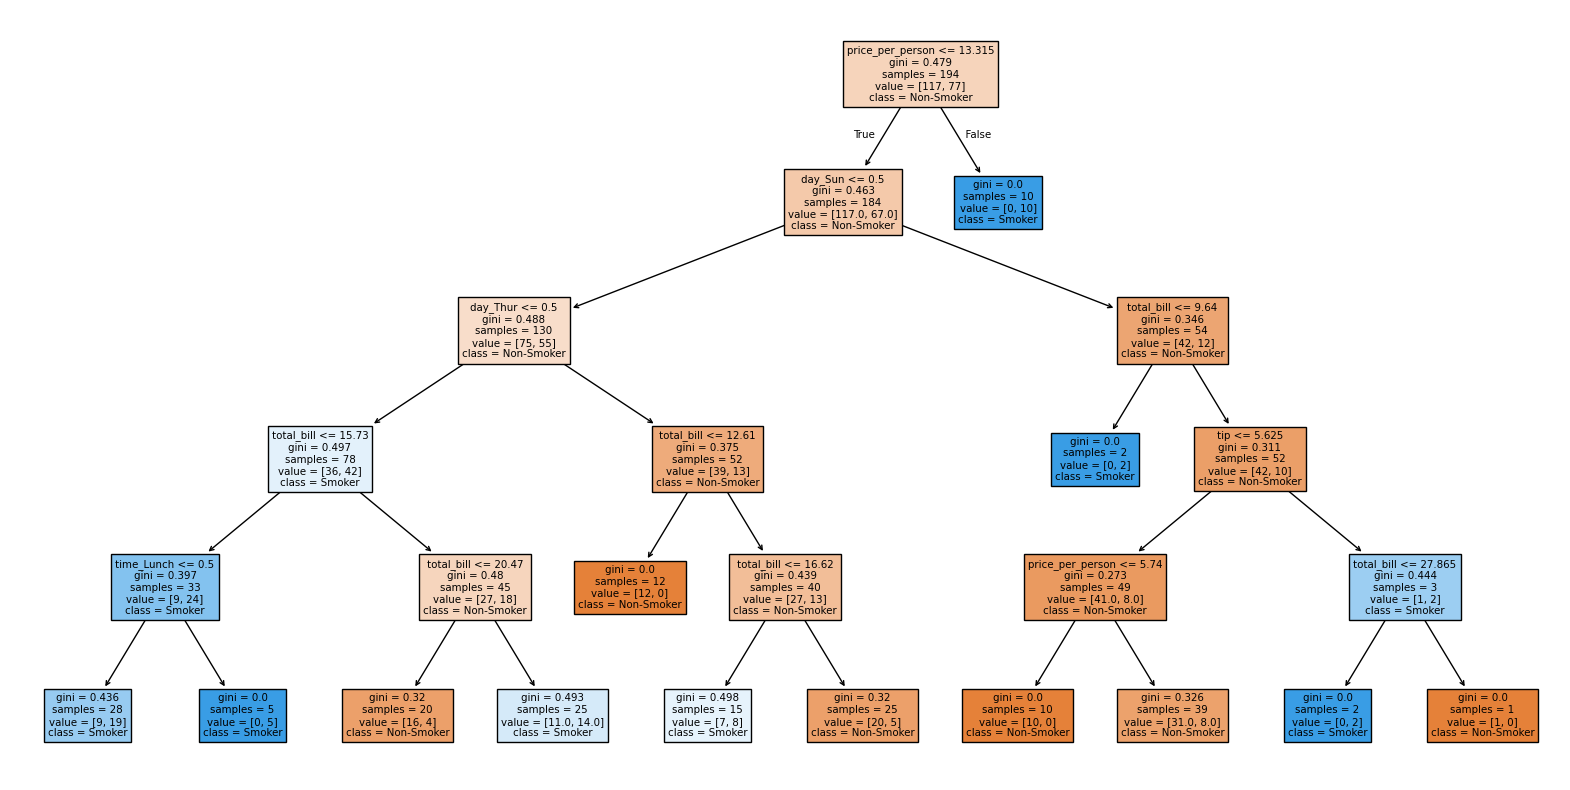

In [70]:
# Q19.

# target and features
y = df2['smoker_Yes']  # target already 0/1
X = df2.drop(['smoker_Yes'], axis=1)  # drop only target
X = pd.get_dummies(X, drop_first=True)  # just in case there are remaining categoricals

# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# training decision tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)  # small tree for simplicity
dt_model.fit(X_train, y_train)

# making predictions
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]  # probability of being smoker


# ---------- Q23. Calculate Accuracy, Precision, Recall, and F1-Score.-------
# evaluating model
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-Score:", f1_score(y_test, y_pred_dt))
# ------------------------------------------------------------------------------

# visualizing tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Non-Smoker','Smoker'], filled=True)
plt.show()  # see which features the tree used first

# Q20. Explain bagging and Random Forest working.

**Bagging** : -

Bagging stands for Bootstrap Aggregating. The idea is to create multiple versions of a dataset by randomly sampling with replacement. Then we train a separate model on each sample. At the end, we average the predictions (for regression) or take a majority vote (for classification). This helps reduce overfitting and makes the model more stable.  

**Random Forest**: -

Random Forest is an extension of bagging using decision trees. In addition to sampling the data, it also randomly selects a subset of features for each split in a tree. This reduces the correlation between trees and improves performance. Finally all trees vote for the output, giving a strong ensemble model that’s more accurate than a single decision tree.

# Q21. Compare Random Forest with Decision Tree.

A **Decision Tree** is a simple model that splits the data step by step based on features to make predictions. It’s easy to understand and visualize because you can see exactly how it decides by following the branches. But a Decision Tree can sometimes **overfit** the training data, meaning it might not do well on new data because it learns too many details that aren’t generally true.

A **Random Forest** is like a group of many Decision Trees working together. It uses a technique called **bagging**, where each tree is trained on a random subset of data and features. Then it combines their results to make a final prediction. This usually makes the model more **accurate and stable** because errors from individual trees cancel out. The Random Forest also gives information on which features are most important for predictions, but it’s harder to visualize all the trees like a single Decision Tree.

In short, Decision Trees are great for understanding how the model works, while Random Forests are better when you want better accuracy and generalization.

Random Forest Performance:
Accuracy: 0.7551020408163265
Precision: 0.6
Recall: 0.6
F1-Score: 0.6
Confusion Matrix:
 [[28  6]
 [ 6  9]]


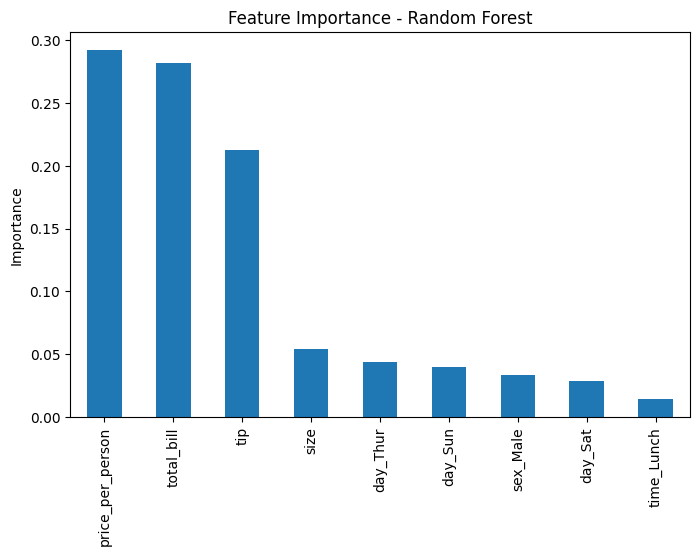

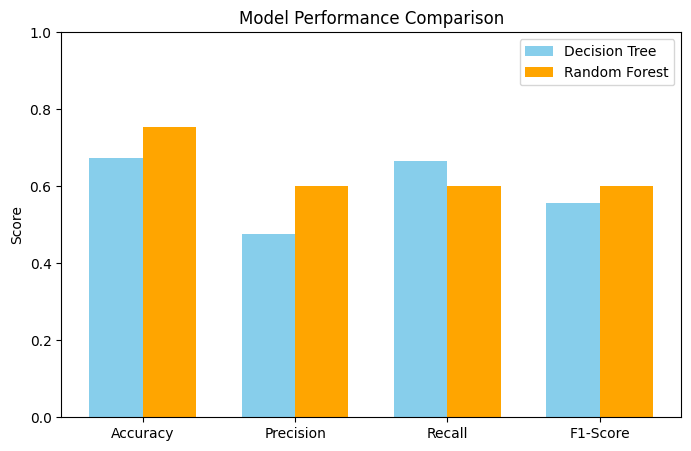

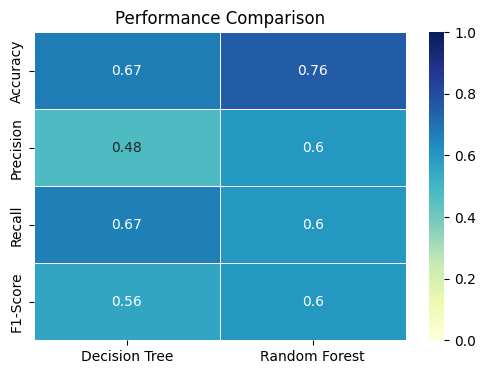

In [81]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

# Metrics
print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

# Feature importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

# Bar plot
plt.figure(figsize=(8,5))
feat_imp.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.show()

# --- Decision Tree Metrics ---
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# --- Random Forest Metrics ---
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Bar Visualization for Comparision of Random Forest and Decision Tree
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
dt_scores = [acc_dt, prec_dt, rec_dt, f1_dt]
rf_scores = [acc_rf, prec_rf, rec_rf, f1_rf]

x = np.arange(len(metrics))  # label positions
width = 0.35  # bar width

plt.figure(figsize=(8,5))
plt.bar(x - width/2, dt_scores, width, label='Decision Tree', color='skyblue')
plt.bar(x + width/2, rf_scores, width, label='Random Forest', color='orange')

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.show()

# Heatmap Visialization
comparison = pd.DataFrame({
    "Decision Tree": dt_scores,
    "Random Forest": rf_scores
}, index=metrics)

plt.figure(figsize=(6,4))
sns.heatmap(comparison, annot=True, cmap="YlGnBu", vmin=0, vmax=1, linewidths = 0.5)
plt.title("Performance Comparison")
plt.show()

Confusion Matrix:
 [[23 11]
 [ 5 10]]


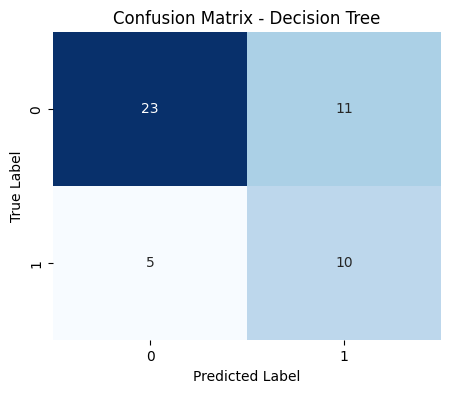

In [82]:
# Q22. Construct Confusion Matrix and explain TP, TN, FP, FN.

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:\n", cm)

# Visualize confusion matrix using heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

Q23. Calculate Accuracy, Precision, Recall, and F1-Score.

I've done the question previously IN Q19. you can see it I've commented the section

# Q24. Compare classification models and recommend the best.

I used two main classification models to predict whether a customer is a smoker: **Decision Tree** and **Random Forest**.  

- **Decision Tree:** This model is simple and easy to interpret. You can see exactly how it makes decisions by following the branches. However, it can **overfit** the training data, meaning it might perform worse on new, unseen data. Its performance metrics like accuracy and precision are good but can vary a lot if the dataset changes.  

- **Random Forest:** This model is an ensemble of many Decision Trees. By combining multiple trees (bagging), it reduces overfitting and improves overall **accuracy, precision, recall, and F1-score**. It also provides **feature importance**, helping us understand which factors matter most. Although it’s harder to visualize all the trees, its predictions are more stable and reliable.  

Based on performance metrics, the **Random Forest is the better choice** because it generalizes better to new data, reduces errors from individual trees, and consistently performs well across all evaluation metrics. The Decision Tree can still be useful if we want interpretability and simple visualization.

# Q25. Summary of Findings and Suggestions for Improvement

In this project, we compared two classification models — Decision Tree and Random Forest — for predicting whether a customer is a smoker. The **Random Forest model performed better overall**, with higher accuracy, precision, and F1-score. This means it made more correct predictions and was more balanced in handling both smokers and non-smokers.

The **feature importance plot** showed that price_per_person, total_bill, and tip were the most influential factors in the model’s decisions. This helps us understand which features matter most when predicting smoking status.

While the results are promising, there is room for improvement. First, collecting more data could help the models learn better and generalize more accurately. Second, tuning model parameters like the number of trees in the Random Forest or trying other algorithms (like Gradient Boosting) could improve performance further. Third, adding new features related to customer habits or demographics might capture more patterns. Lastly, applying techniques like cross-validation and feature engineering would also strengthen the model.

Overall, this project demonstrates how ensemble methods like Random Forest reduce overfitting and increase prediction reliability compared to a single Decision Tree.

### **Assignment 3**


In [84]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image_dataset_from_directory, image
import matplotlib.pyplot as plt

Explain why preprocessing is important in deep learning.

Preprocessing is really important in deep learning because it gets the raw data ready so the model can learn from it properly. This usually means doing things like resizing images to the same size, normalizing pixel values so they’re on a similar scale, and cleaning the data by removing noise or unwanted parts. When the data is preprocessed well, the model trains faster and works better. It also helps the model understand patterns more easily and lowers the chance of mistakes while training.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

# Load dataset
train_dataset = image_dataset_from_directory(
    '/content/drive/MyDrive/ANN Assignment Dataset/Training',
    image_size = (64, 64),
    batch_size = 32,

)

test_dataset = image_dataset_from_directory(
    '/content/drive/MyDrive/ANN Assignment Dataset/Testing',
    image_size = (64, 64),
    batch_size = 32,

)

# Prefetch for faster training
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# Normalize the values
normalization_layer = tf.keras.layers.Rescaling(1./255)


train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x) ,y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))



Found 1137 files belonging to 4 classes.
Found 428 files belonging to 4 classes.


In [ ]:
model = Sequential([

    Flatten(input_shape=(64, 64, 3)),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(4, activation='softmax')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

b) Explain why categorical crossentropy is used in multi-class classification.

Categorical crossentropy is used in multi-class classification because it helps check how close the predicted probabilities are to the real class labels. In these problems, each input belongs to one class out of many, and the model gives probabilities for all classes using a softmax layer. Categorical crossentropy measures the difference between what the model predicts and what the correct answer is. This way, the model knows how to adjust itself during training to get better and more accurate at classifying.

In [ ]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights=True
)

Explain the purpose of Early Stopping.

Early stopping is a trick used during training to stop the model from overfitting. Basically, we keep an eye on how well the model does on validation data, and if it stops getting better for a few rounds (epochs), we stop training. This prevents the model from just memorizing the training data and wasting time. Using early stopping helps the model work better on new data and also saves training time.

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 417s 11s/step - accuracy: 0.2398 - loss: 5.1268 - val_accuracy: 0.3949 - val_loss: 1.5640
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 19s 539ms/step - accuracy: 0.3176 - loss: 1.4581 - val_accuracy: 0.3201 - val_loss: 1.3299
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 563ms/step - accuracy: 0.3340 - loss: 1.3300 - val_accuracy: 0.4206 - val_loss: 1.2916
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 499ms/step - accuracy: 0.3775 - loss: 1.3270 - val_accuracy: 0.4229 - val_loss: 1.2203
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 508ms/step - accuracy: 0.4084 - loss: 1.2264 - val_accuracy: 0.4393 - val_loss: 1.1844
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 593ms/step - accuracy: 0.3257 - loss: 1.2999 - val_accuracy: 0.2547 - val_loss: 1.2688
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 510ms/step - accuracy: 0.3556 - loss: 1.2507 - val_accuracy: 0.3458 - val_loss: 1.3408
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 504ms/step - accuracy: 0.3719 - loss: 1.2819 - val_accur

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 537ms/step - accuracy: 0.4579 - loss: 1.1992
Test Loss: 1.1844
Test Accuracy: 0.4393


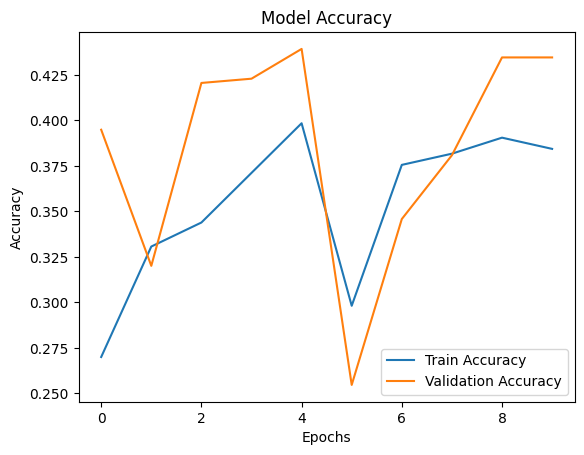

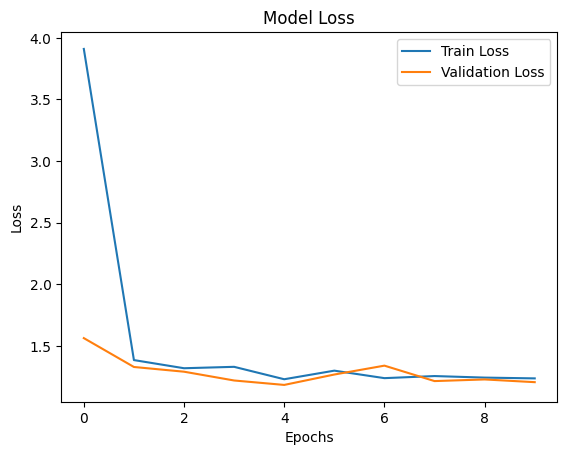

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


In [ ]:
img = image.load_img('/content/drive/MyDrive/ANN Assignment Dataset/Testing/butter_naan/001.jpg',target_size=(64, 64))
img_arr = image.img_to_array(img)/ 255.0
img_arr = np.expand_dims(img_arr, axis = 0)

class_names = ['Butter Naan', 'Chapati', 'Chole Bhature', 'Kadai Paneer']

# Predict
pred_probs = model.predict(img_arr)        # Model outputs probabilities
pred_class = np.argmax(pred_probs, axis=1)   # Get index of highest probability
pred_label = class_names[pred_class[0]]      # Map index to class name

print(f"Predicted Class: {pred_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Class: Chole Bhature


1. Why is ANN not ideal for image classification compared to CNN?

Artificial Neural Networks (ANNs) aren’t the best for image classification because they flatten the image into a long vector, which makes the model ignore the spatial relationships between pixels. This means it’s harder for the network to notice patterns like edges, shapes, or textures. Convolutional Neural Networks (CNNs) are better because they have convolution layers that can detect these patterns and features while using fewer parameters, making them much more suitable for working with images.


2. What challenges did you face during training?

One of the main problems during training was overfitting, which happened when the model did really well on the training data but not as well on the validation data. Another challenge was figuring out the best hyperparameters, like learning rate, batch size, and number of epochs, to make the model perform better. Training also took a lot of time, especially with bigger datasets or deeper networks.

3. How can the model performance be improved?

The model can be improved by using more data and applying data augmentation, like flipping, rotating, or scaling images. Changing hyperparameters, like learning rate and batch size, can also help the model train better. Using techniques like dropout or batch normalization can reduce overfitting. We could also try more advanced architectures or use transfer learning with pre-trained models to get better accuracy.

# **Assignment 4**


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing import image, image_dataset_from_directory
import matplotlib.pyplot as plt

import numpy as np

In [3]:
AUTOTUNE = tf.data.AUTOTUNE

# Loading the Dataset
train_dataset = image_dataset_from_directory(
    '/content/drive/MyDrive/Dataset ANN/training_set/training_set',
    image_size = (64, 64),
    batch_size = 32,
    label_mode = 'binary'
)

# Reason to use shuffle: evaluation becomes deterministic.
# But even without this, your code will still work fine.

test_dataset = image_dataset_from_directory(
    '/content/drive/MyDrive/Dataset ANN/test_set/test_set',
    image_size = (64, 64),
    batch_size = 32,
    label_mode = 'binary',
    shuffle = False
)

# Prefetch for faster training
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# Normalization
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))


Found 7745 files belonging to 2 classes.
Found 2283 files belonging to 2 classes.


### Explain why preprocessing (resizing, normalization, augmentation) is important in deep learning.

Preprocessing is important in deep learning because it prepares raw data so the model can learn from it properly.

Resizing ensures that all images have the same dimensions so they can be processed by the neural network.

Normalization scales pixel values (usually from 0–255 to 0–1), which helps the model train faster and more smoothly.

Data augmentation creates modified versions of images like flipping, rotating, or zooming. This increases the dataset size and helps the model generalize better.

Overall, preprocessing improves training performance and reduces overfitting.

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


243/243 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.5088 - loss: 0.7111 - val_accuracy: 0.4525 - val_loss: 0.7334
Epoch 2/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 82s 338ms/step - accuracy: 0.5499 - loss: 0.6895 - val_accuracy: 0.6277 - val_loss: 0.6419
Epoch 3/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 82s 338ms/step - accuracy: 0.6276 - loss: 0.6523 - val_accuracy: 0.6986 - val_loss: 0.5962
Epoch 4/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 83s 340ms/step - accuracy: 0.6971 - loss: 0.5858 - val_accuracy: 0.7127 - val_loss: 0.5757
Epoch 5/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 84s 344ms/step - accuracy: 0.7422 - loss: 0.5358 - val_accuracy: 0.7236 - val_loss: 0.5569
Epoch 6/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 83s 340ms/step - accuracy: 0.7759 - loss: 0.4737 - val_accuracy: 0.6938 - val_loss: 0.6100
Epoch 7/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 83s 340ms/step - accuracy: 0.8138 - loss: 0.4210 - val_accuracy: 0.7350 - val_loss: 0.5602
Epoch 8/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 82s 339ms/step - accuracy: 0.8462 - loss: 0.3546 - val_a

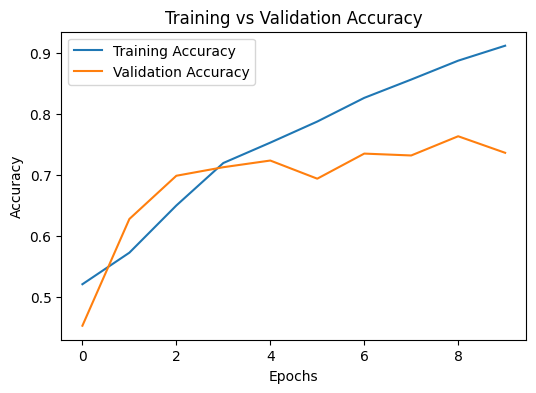

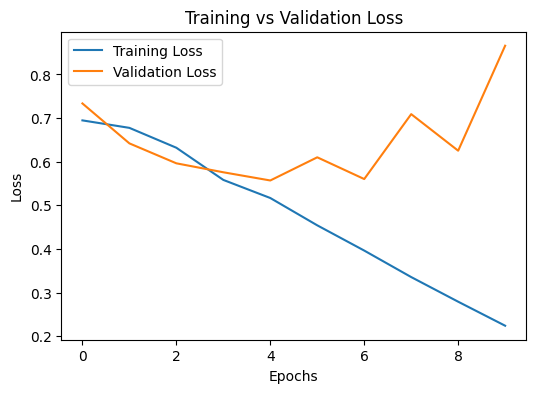

In [4]:
model = Sequential()

# First conv layer + pooling
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))  # 32 filters, 3x3 kernel
model.add(MaxPooling2D(pool_size=(2,2)))  # makes the image smaller and keeps important features
# This layer helps model see basic things like edges and shapes

# Second conv layer + pooling
model.add(Conv2D(64, (3,3), activation='relu'))  # more filters for deeper patterns
model.add(MaxPooling2D(pool_size=(2,2)))  # reduce size again
# Now the model can learn more complex stuff from images

# Flatten the data so we can put it in Dense layers
model.add(Flatten())  # turn 2D feature maps into 1D vector

# First dense layer + dropout
model.add(Dense(128, activation='relu'))  # fully connected layer to combine features
model.add(Dropout(0.5))  # randomly turn off 50% of neurons to avoid overfitting

# Second dense layer + dropout
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))  # again helps prevent overfitting

# Output layer
model.add(Dense(1, activation='sigmoid'))  # output 0 or 1 for Cat or Dog

# Model Compiling

model.compile(
    optimizer='adam',              # Adam optimizer makes training faster
    loss='binary_crossentropy',    # binary because only Cat or Dog
    metrics=['accuracy']           # track accuracy during training
)


# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',   # watch validation loss
    patience=5,           # stop if it doesn't get better after 5 epochs
    restore_best_weights=True
)

# Training Model
history = model.fit(
    train_dataset,           # training data
    validation_data=test_dataset,  # check performance on testing data
    epochs=50,               # max number of times to go through dataset
    callbacks=[early_stop]   # apply early stopping
)

# Evaluate model performance on test data
test_loss, test_accuracy = model.evaluate(test_dataset)

print("\n \nTest Loss:", test_loss)
print("\n \nTest Accuracy:", test_accuracy)



# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

###Q. Roles of Different Layers : -
Conv2D Layer:
The Conv2D layer is used to detect important features from images such as edges, shapes, and textures. It applies multiple filters to the image and creates feature maps that help the model understand patterns in the image.

MaxPooling2D:
MaxPooling2D is used to reduce the size of the feature maps while keeping the most important information. This helps make the model faster and reduces the number of parameters.

ReLU Activation:
ReLU (Rectified Linear Unit) is an activation function that converts negative values to zero and keeps positive values unchanged. It helps the model learn complex patterns and also makes training faster.

Sigmoid Activation:
Sigmoid is used in the output layer for binary classification problems. It converts the output into a probability value between 0 and 1, which helps decide whether the image belongs to one class or the other (for example, cat or dog).

Dropout:
Dropout is a regularization technique used to prevent overfitting. It randomly turns off some neurons during training so the model does not rely too much on specific features.

###Q. Explain why Binary Crossentropy is used in binary classification.

Binary Crossentropy is used in binary classification because the problem has only two possible classes (for example, Cat or Dog). This loss function measures the difference between the predicted probability and the actual class label.

It works well with the sigmoid activation function, which outputs values between 0 and 1 representing probabilities. Binary crossentropy helps the model adjust its weights during training so that the predicted probabilities become closer to the actual labels.

Because of this, it is commonly used for binary classification tasks in deep learning models.

###Q. Explain the purpose of Early Stopping.

Early stopping is a technique used to stop the training process when the model stops improving on validation data. During training, the model’s performance on the validation set is monitored, and if the validation loss does not improve for several epochs, training is stopped.

The purpose of early stopping is to prevent overfitting and avoid unnecessary training. It also saves time and ensures that the model keeps the best weights that gave the best validation performance.

### Q. Interpret whether the model is overfitting or underfitting

The accuracy and loss graphs show that the model is overfitting the training data. The training accuracy keeps getting better and reaches over 90 percent. This means the model is learning the training data very well. But the validation accuracy stays around 70 to 75 percent and does not improve much after a few epochs. This difference between training and validation accuracy shows the model is not generalizing well to new data.

The training loss keeps going down while the validation loss starts going up after some time. When this happens it usually means the model is overfitting. It is memorizing the training examples instead of learning general patterns. So the model fits the training data too closely but does not perform as well on new data.

To fix this overfitting, some methods can be used. Dropout is already applied which helps. Other options are to make the model simpler or to collect more data. These steps can help the model learn better and work well on unseen data.

### Q. Why is CNN better than ANN for image classification?

CNNs are better than ANNs for image classification because they can understand spatial patterns in images. ANNs treat all input pixels independently, which means they lose information about how pixels are related to each other. CNNs use convolutional layers to detect edges, shapes, and textures. They also use pooling layers to reduce the image size while keeping important features. This makes CNNs more effective at recognizing objects in images and requires fewer parameters than a fully connected ANN.

### Q. What challenges did you face during training?

During training, one of the main challenges was overfitting. The model performed very well on the training data but not as well on validation data. Another challenge was tuning hyperparameters like learning rate, batch size, and number of epochs. These settings can affect how quickly the model learns and how well it generalizes. Training also took a long time since images are high-dimensional data and the network had multiple layers.

### Q. How can the model performance be improved?

The model performance can be improved in several ways. Increasing the dataset size or applying data augmentation like flipping, rotating, and scaling images can help the model learn more general patterns. Adjusting hyperparameters such as learning rate and batch size can also improve results. Using regularization techniques like dropout or batch normalization reduces overfitting. Finally, more advanced architectures or transfer learning with pre-trained models can give better accuracy.

In [7]:
# Preditcion of a specific image
img_path = '/content/drive/MyDrive/Dataset ANN/test_set/test_set/dogs/dog.4007.jpg'
img = image.load_img(img_path, target_size=(64,64))  # resizing img to training size
img_array = image.img_to_array(img)/255.0           # normalize pixels
img_array = np.expand_dims(img_array, axis=0)       # add batch dimension

prediction = model.predict(img_array)  # predict
pred_label = 'Dog' if prediction[0][0] > 0.5 else 'Cat'  # threshold 0.5
print("Predicted Label:", pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Label: Dog


# **Assignment 5**

### 1. What is image processing? Explain its importance in computer vision.
Image processing is the technique of analyzing and manipulating digital images to enhance their quality or extract useful information. It is important in computer vision because it helps machines understand images, detect objects, recognize patterns, and make decisions based on visual data. Without preprocessing or image processing, models may fail to correctly interpret raw pixel data.

### 2. What is video processing? How is it different from image processing?
Video processing deals with sequences of images (frames) over time. Unlike image processing, which focuses on a single image, video processing analyzes motion, detects changes between frames, and can track objects over time. Video processing is used in applications like surveillance, action recognition, and real-time monitoring.

### 3. What is the role of OpenCV in image and video processing?
OpenCV is a widely used open-source library for computer vision. It provides tools for reading, writing, and manipulating images and videos. It also offers functions for filtering, transformations, object detection, edge detection, and more. Using OpenCV makes it easier to implement complex vision algorithms efficiently.

### 4. What is NumPy and why is it important for image processing?
NumPy is a Python library for numerical computing. Images are essentially arrays of pixel values, so NumPy is essential for manipulating, analyzing, and performing mathematical operations on images. It allows us to slice, index, and modify images efficiently.

### 5. Explain how an image is represented in the form of a NumPy array.
An image is represented as a multi-dimensional NumPy array. For grayscale images, it is a 2D array with shape (height, width). For color images, it is a 3D array with shape (height, width, channels) where channels represent Red, Green, and Blue (RGB). Each element of the array corresponds to a pixel value ranging from 0 to 255

### **Part B: Image Processing using OpenCV**

In [11]:
# Part B: Image Processing using OpenCV (Colab-friendly)

from google.colab.patches import cv2_imshow
import cv2

# 1. Read and display an image
img = cv2.imread('/content/drive/MyDrive/ANN Assignment Dataset/Testing/chole_bhature/002.jpg')
cv2_imshow(img)  # display image in Colab

# 2. Convert a colored image into grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

# 3. Resize image to 300x300
resized = cv2.resize(img, (300, 300))
cv2_imshow(resized)

# 4. Apply Gaussian blur
blurred = cv2.GaussianBlur(img, (5, 5), 0)  # kernel size 5x5
cv2_imshow(blurred)

# 5. Edge detection using Canny
edges = cv2.Canny(img, 100, 200)  # thresholds 100 and 200
cv2_imshow(edges)

# 6. Binary thresholding
gray_for_thresh = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # need grayscale
_, thresh = cv2.threshold(gray_for_thresh, 127, 255, cv2.THRESH_BINARY)
cv2_imshow(thresh)

# 7. Flip image horizontally and vertically
flip_h = cv2.flip(img, 1)  # horizontal
flip_v = cv2.flip(img, 0)  # vertical
cv2_imshow(flip_h)
cv2_imshow(flip_v)

# 8. Rotate image by 90 degrees clockwise
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
matrix = cv2.getRotationMatrix2D(center, -90, 1.0)  # -90 for clockwise
rotated = cv2.warpAffine(img, matrix, (w, h))
cv2_imshow(rotated)

# 9. Crop a portion of the image
# let's crop the middle rectangle
start_row, start_col = h//4, w//4
end_row, end_col = start_row + h//2, start_col + w//2
cropped = img[start_row:end_row, start_col:end_col]
cv2_imshow(cropped)

# 10. Adjust brightness and contrast
alpha = 1.2  # contrast (1.0 = original)
beta = 50    # brightness (0 = original)
adjusted = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
cv2_imshow(adjusted)

Output hidden; open in https://colab.research.google.com to view.

### **Part C: Video Processing using OpenCV**

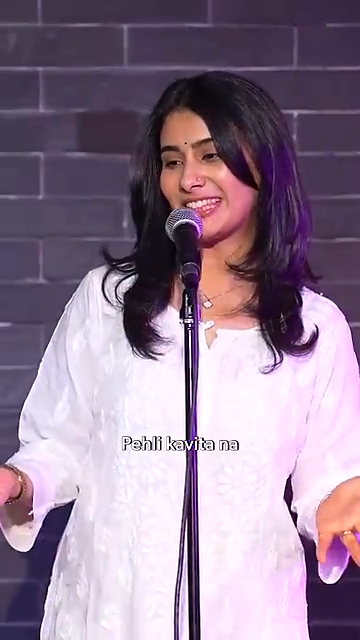

Webcam Live
Webcam FPS: 0.0
Video saved as output.avi
None
None


In [16]:
# Colab-friendly Video Processing
from google.colab.patches import cv2_imshow
import cv2
from IPython.display import clear_output
import time

# Utility function to show a single frame in Colab
def show_frame(frame, title='Frame'):
    clear_output(wait=True)
    cv2_imshow(frame)
    print(title)

##############################
# 1. Capture live video (display limited frames)
##############################
# cap = cv2.VideoCapture(0)
cap = cv2.VideoCapture('/content/drive/MyDrive/Ache Teachers _ Teachers Day Special Poetry.mp4')
ret, frame = cap.read()
frame = cv2.resize(frame, (640, 480))
for i in range(50):  # display 50 frames
    ret, frame = cap.read()
    if not ret:
        print("Cannot capture frame")
        break
    show_frame(frame, title='Webcam Live')
    time.sleep(0.05)
cap.release()

##############################
# 2. Convert live video frames to grayscale
##############################
cap = cv2.VideoCapture(0)
for i in range(50):
    ret, frame = cap.read()
    if not ret:
        break
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    show_frame(gray_frame, title='Grayscale Video')
    time.sleep(0.05)
cap.release()

##############################
# 3. Edge detection on live video frames
##############################
cap = cv2.VideoCapture(0)
for i in range(50):
    ret, frame = cap.read()
    if not ret:
        break
    edges_frame = cv2.Canny(frame, 100, 200)
    show_frame(edges_frame, title='Edge Detection')
    time.sleep(0.05)
cap.release()

##############################
# 4. Display frame rate (FPS)
##############################
cap = cv2.VideoCapture(0)
fps = cap.get(cv2.CAP_PROP_FPS)
print("Webcam FPS:", fps)
cap.release()

##############################
# 5. Record video from webcam (save as output.avi)
##############################
cap = cv2.VideoCapture(0)
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('output.avi', fourcc, 20.0, (640,480))
for i in range(100):  # record 100 frames
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)
    show_frame(frame, title='Recording Video')
    time.sleep(0.05)
cap.release()
out.release()
print("Video saved as output.avi")

##############################
# 6. Capture and save a single frame
##############################
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
if ret:
    cv2.imwrite('frame.jpg', frame)
    print("Single frame saved as frame.jpg")
print(cap.release())

##############################
# 7. Detect motion using frame differencing
##############################
cap = cv2.VideoCapture(0)
ret, prev_frame = cap.read()
if ret:
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    for i in range(50):  # detect motion for 50 frames
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        diff = cv2.absdiff(prev_gray, gray)
        show_frame(diff, title='Motion Detection')
        prev_gray = gray
        time.sleep(0.05)
print(cap.release())

### **Part D: NumPy Operations in Image Processing**

In [17]:
# Import libraries
import cv2
from google.colab.patches import cv2_imshow

# Choose source: webcam (0) or a video file
# For Colab, video file is more reliable
video_path = '/content/drive/MyDrive/Ache Teachers _ Teachers Day Special Poetry.mp4'  # put your video path here
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
else:
    print("Video opened successfully.")

# Process a few frames for demo purposes (Colab might crash on long videos)
frame_count = 0
max_frames = 50  # number of frames to process

while frame_count < max_frames:
    ret, frame = cap.read()
    if not ret:
        print("No more frames or cannot read frame.")
        break

    # Resize frame to reduce memory usage
    frame = cv2.resize(frame, (640, 480))

    # 1. Display original frame
    print("Original Frame:")
    cv2_imshow(frame)

    # 2. Convert to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    print("Grayscale Frame:")
    cv2_imshow(gray_frame)

    # 3. Edge detection using Canny
    edges_frame = cv2.Canny(frame, 100, 200)
    print("Edges Frame:")
    cv2_imshow(edges_frame)

    frame_count += 1

cap.release()
print("Finished processing video frames.")

# 4. Record video (optional)
# This will save the video after resizing frames
cap = cv2.VideoCapture(video_path)
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('output_resized.avi', fourcc, 20.0, (640,480))

frame_count = 0
while frame_count < max_frames:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.resize(frame, (640, 480))
    out.write(frame)
    frame_count += 1

cap.release()
out.release()
print("Video saved as output_resized.avi")

# 5. Capture and save a single frame
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
if ret:
    frame = cv2.resize(frame, (640,480))
    cv2.imwrite('single_frame.jpg', frame)
    print("Single frame saved as single_frame.jpg")
cap.release()

Output hidden; open in https://colab.research.google.com to view.